In [7]:
import pathlib
import numpy as np
import pyreadr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import norm

In [8]:
# ── 1. Load posterior draws ───────────────────────────────────────────────────
 
data_path = pathlib.Path('Data') / 'bayesm_output_margarine_1comp_rawX.RData'
 
rdata  = pyreadr.read_r(str(data_path))
mu_df  = rdata['mu_draws_df']    # (R, 6)  — μ_1^r  for each draw r
cov_df = rdata['cov_draws_df']   # (R, 36) — Σ_1^r flattened row-by-row
 
mu  = mu_df.values.astype(float)   # (R, 6)
cov = cov_df.values.astype(float)  # (R, 36)
 
R, nvar = mu.shape
print(f'Draws: {R},  parameters (nvar): {nvar}')

Draws: 5000,  parameters (nvar): 6


In [9]:
# ── 2. Marginal standard deviations  √Σ_r[j,j] ───────────────────────────────
#
# Σ is stored row-by-row, so the diagonal element (j, j) is at
# flattened index  j * nvar + j.
 
diag_idx = np.array([j * nvar + j for j in range(nvar)])  # [0,7,14,21,28,35]
std_diag = np.sqrt(cov[:, diag_idx])                      # (R, 6)

In [10]:
# ── 3. Evaluate equation (5.5.19) for K = 1 ──────────────────────────────────
#
# For each parameter j, evaluate on a grid x of N_GRID points:
#
#   d̄_j(x) = (1/R) * Σ_r  N(x ; μ_r[j], √Σ_r[j,j])
#
# Vectorised: build (N_GRID, R) pdf matrix, then average over axis=1.
 
N_GRID = 500
grids     = []
densities = []

for j in range(nvar):
    mu_j  = mu[:, j]
    std_j = std_diag[:, j]

    # Tighter grid: mean ± 4 * pooled spread
    # (covers >99.99 % of the averaged density without excessive padding)
    spread = np.sqrt(std_j.mean()**2 + mu_j.var())   # pooled SD
    centre = mu_j.mean()
    lo = centre - 4 * spread
    hi = centre + 4 * spread
    x  = np.linspace(lo, hi, N_GRID)

    pdf_matrix = norm.pdf(
        x[:, None],
        loc=mu_j[None, :],
        scale=std_j[None, :]
    )

    grids.append(x)
    densities.append(pdf_matrix.mean(axis=1))

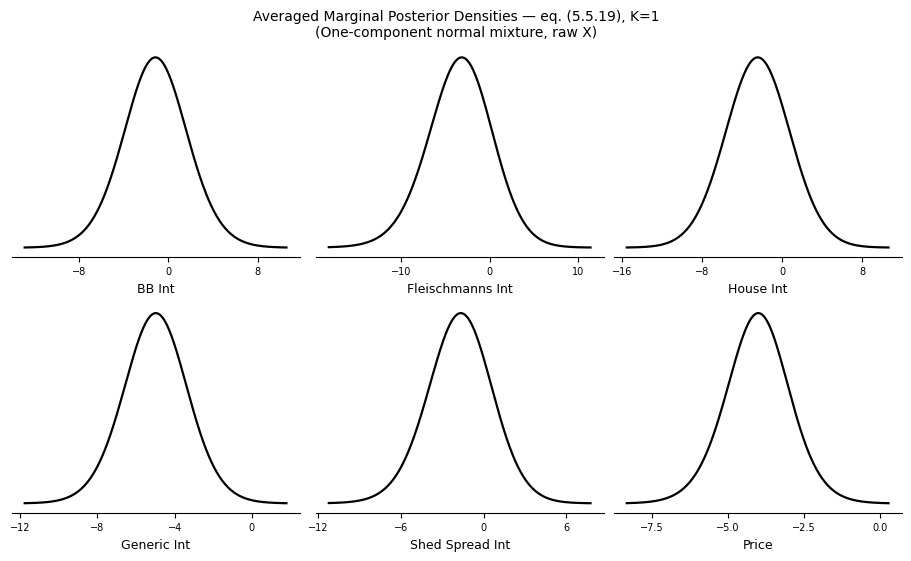

In [11]:
# ── 4. Plot — Figure 5.6 style ────────────────────────────────────────────────
 
plot_labels = [
    'BB Int', 'Fleischmanns Int', 'House Int',
    'Generic Int', 'Shed Spread Int', 'Price'
]
 
fig, axes = plt.subplots(
    nrows=2, ncols=3,
    figsize=(9, 5.5),
    constrained_layout=True
)
 
for idx, ax in enumerate(axes.flat):
    ax.plot(grids[idx], densities[idx], color='black', linewidth=1.6)
 
    ax.set_xlabel(plot_labels[idx], fontsize=9)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='x', labelsize=7)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4, integer=False))
 
fig.suptitle(
    'Averaged Marginal Posterior Densities — eq. (5.5.19), K=1\n'
    '(One-component normal mixture, raw X)',
    fontsize=10
)
 
plt.show()

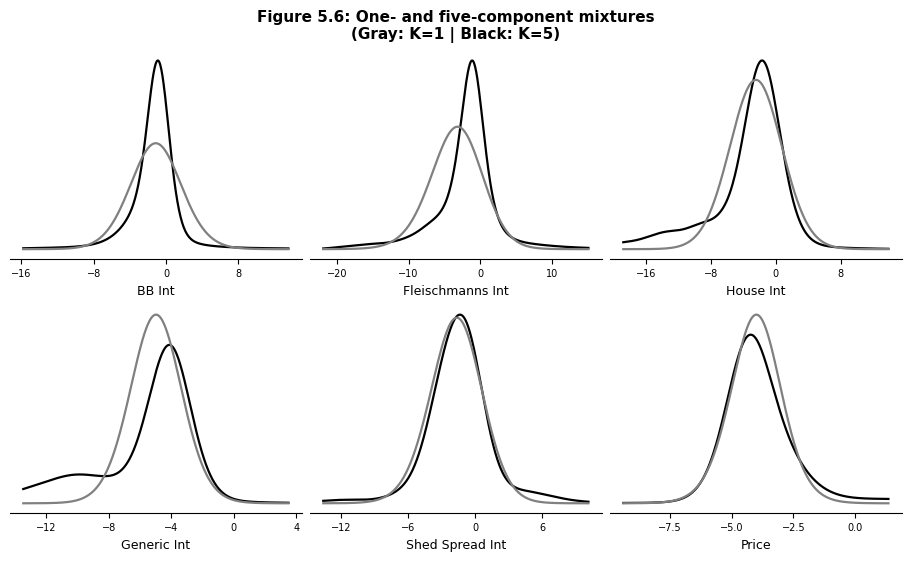

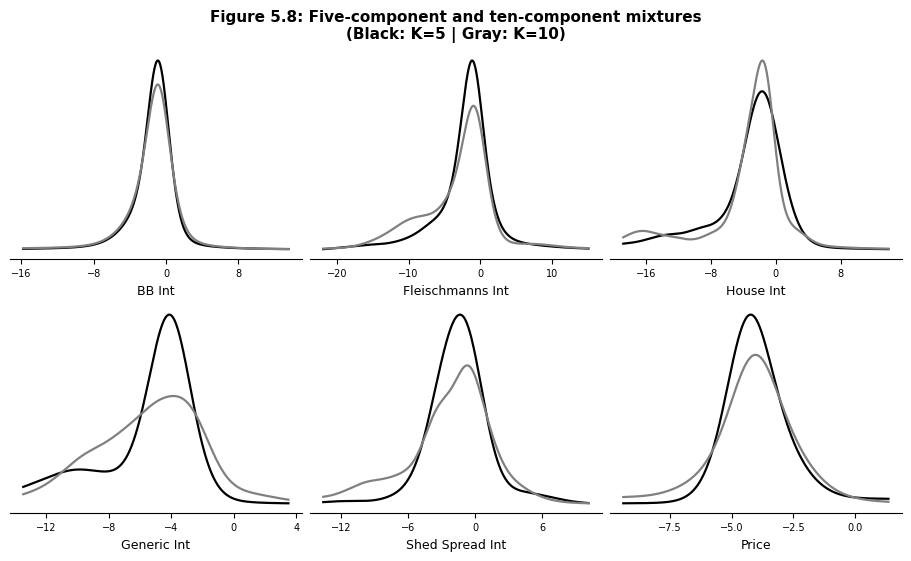

In [12]:
import pathlib
import numpy as np
import pyreadr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import norm

# ── 1. Data Loader Helper ──────────────────────────────────────────────────────
def load_and_format_draws(filepath, K, nvar=6):
    """
    Loads RData containing mu, cov, and pvec. 
    Returns formatted numpy arrays:
      mu:   (R, K, nvar)
      std:  (R, K, nvar) - extracted from the diagonals of cov
      pvec: (R, K)       - mixture probabilities
    """
    rdata = pyreadr.read_r(str(filepath))
    
    # Extract DataFrames
    mu_df = rdata['mu_draws_df']
    cov_df = rdata['cov_draws_df']
    
    # For K=1, pvec might not be explicitly saved since it's always 1.
    if 'pvec_draws_df' in rdata:
        pvec = rdata['pvec_draws_df'].values.astype(float)
    else:
        pvec = np.ones((mu_df.shape[0], K))
        
    mu_raw = mu_df.values.astype(float)
    cov_raw = cov_df.values.astype(float)
    R = mu_raw.shape[0]
    
    # Reshape mu to (R, K, nvar)
    mu = mu_raw.reshape((R, K, nvar))
    
    # Extract standard deviations (diagonals of flattened covariance matrices)
    std = np.zeros((R, K, nvar))
    for k in range(K):
        # Assuming cov is stored as [cov_comp1, cov_comp2, ... cov_compK]
        # where each is flattened row-by-row
        cov_k = cov_raw[:, k * (nvar * nvar) : (k + 1) * (nvar * nvar)]
        diag_idx = [j * nvar + j for j in range(nvar)]
        std[:, k, :] = np.sqrt(cov_k[:, diag_idx])
        
    return mu, std, pvec

# ── 2. Equation (5.5.19) Evaluator ───────────────────────────────────────────
def compute_marginal_densities(mu, std, pvec, grids):
    """
    Evaluates Eq (5.5.19) for any K number of components.
    """
    R, K, nvar = mu.shape
    densities = []

    for j in range(nvar):
        x = grids[j] # Shape (N_GRID,)
        density_j = np.zeros_like(x)
        
        # Loop through components to save memory (avoids massive 3D arrays)
        for k in range(K):
            # Evaluate PDF for component k across all draws R: shape (N_GRID, R)
            pdf_k = norm.pdf(x[:, None], loc=mu[:, k, j], scale=std[:, k, j])
            
            # Weight by pvec and average over the R draws
            density_j += np.mean(pvec[:, k] * pdf_k, axis=1)
            
        densities.append(density_j)
        
    return densities

# ── 3. Load Data & Define Shared Grids ───────────────────────────────────────
data_dir = pathlib.Path('Data')

# Load the draws (ensure paths map to your actual RData files)
mu1, std1, pvec1 = load_and_format_draws(data_dir / 'bayesm_output_margarine_1comp_rawX.RData', K=1)
mu5, std5, pvec5 = load_and_format_draws(data_dir / 'bayesm_output_margarine_5comp_rawX.RData', K=5)
mu10, std10, pvec10 = load_and_format_draws(data_dir / 'bayesm_output_margarine_10comp_rawX.RData', K=10)

R, _, nvar = mu1.shape
N_GRID = 500
grids = []

# Create unified grids across all parameters so distributions align perfectly
for j in range(nvar):
    # Base the grid spread on K=1, widened slightly to catch complex K=5/10 tails
    pooled_sd = np.sqrt(std1[:, 0, j].mean()**2 + mu1[:, 0, j].var())
    centre = mu1[:, 0, j].mean()
    grids.append(np.linspace(centre - 5 * pooled_sd, centre + 5 * pooled_sd, N_GRID))

# Compute densities
densities_K1  = compute_marginal_densities(mu1, std1, pvec1, grids)
densities_K5  = compute_marginal_densities(mu5, std5, pvec5, grids)
densities_K10 = compute_marginal_densities(mu10, std10, pvec10, grids)

# ── 4. Plotting Functions ────────────────────────────────────────────────────
plot_labels = [
    'BB Int', 'Fleischmanns Int', 'House Int',
    'Generic Int', 'Shed Spread Int', 'Price'
]

def plot_density_comparison(dens_A, dens_B, color_A, color_B, title, filename=None):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(9, 5.5), constrained_layout=True)
    
    for idx, ax in enumerate(axes.flat):
        ax.plot(grids[idx], dens_A[idx], color=color_A, linewidth=1.6)
        ax.plot(grids[idx], dens_B[idx], color=color_B, linewidth=1.6)
        
        ax.set_xlabel(plot_labels[idx], fontsize=9)
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='x', labelsize=7)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=False))
        
    fig.suptitle(title, fontsize=11, fontweight='bold')
    plt.show()

# ── Figure 5.6: 1-Component (Gray) vs 5-Component (Black) ────────────────────
plot_density_comparison(
    dens_A=densities_K5, 
    dens_B=densities_K1, 
    color_A='black', 
    color_B='gray', 
    title='Figure 5.6: One- and five-component mixtures\n(Gray: K=1 | Black: K=5)'
)

# ── Figure 5.8: 5-Component (Black) vs 10-Component (Gray) ───────────────────
plot_density_comparison(
    dens_A=densities_K5, 
    dens_B=densities_K10, 
    color_A='black', 
    color_B='gray', 
    title='Figure 5.8: Five-component and ten-component mixtures\n(Black: K=5 | Gray: K=10)'
)